# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [3]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [5]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

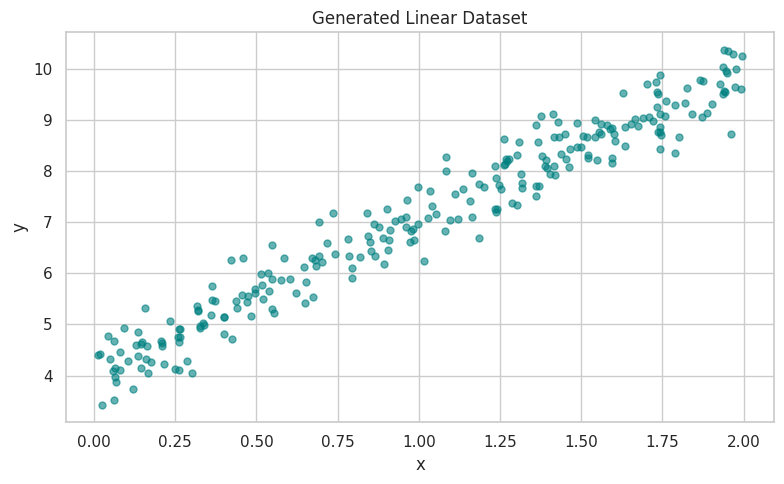

,Method,Final MSE,Training Time (s),Final Theta
0,Batch GD,0.232593,0.028254,"[3.5725093793727596, 3.3699890653902695]"
1,SGD,0.163731,0.102826,"[4.1293176788061245, 2.9686544870462637]"
2,Mini-Batch GD,0.159304,0.032480,"[4.080240413454181, 2.9562434144967558]"


In [6]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

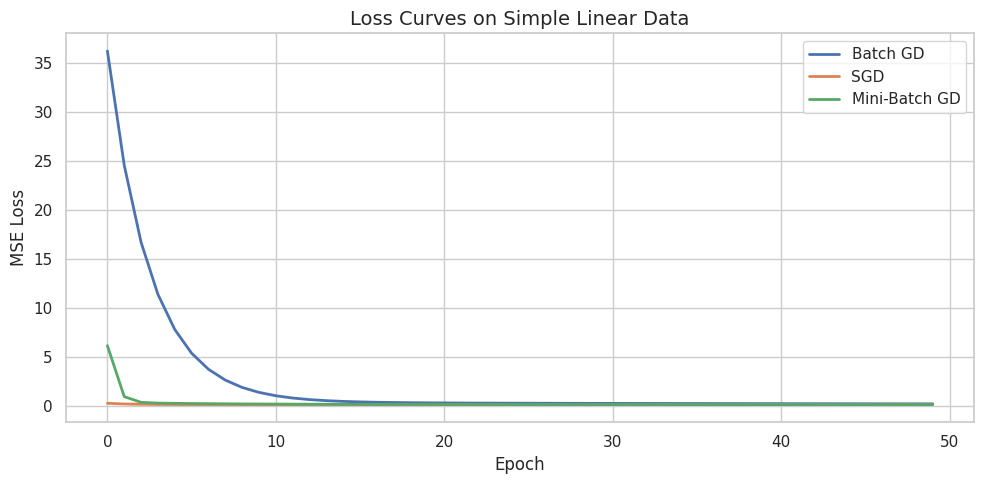

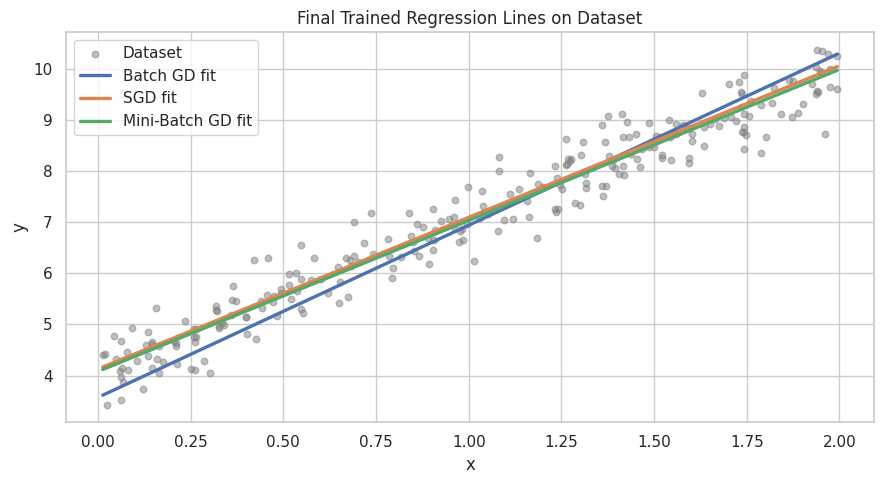

,Method,Final MSE,Training Time (s),Final Theta
2,Mini-Batch GD,0.159304,0.032480,"[4.080240413454181, 2.9562434144967558]"
1,SGD,0.163731,0.102826,"[4.1293176788061245, 2.9686544870462637]"
0,Batch GD,0.232593,0.028254,"[3.5725093793727596, 3.3699890653902695]"


In [7]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

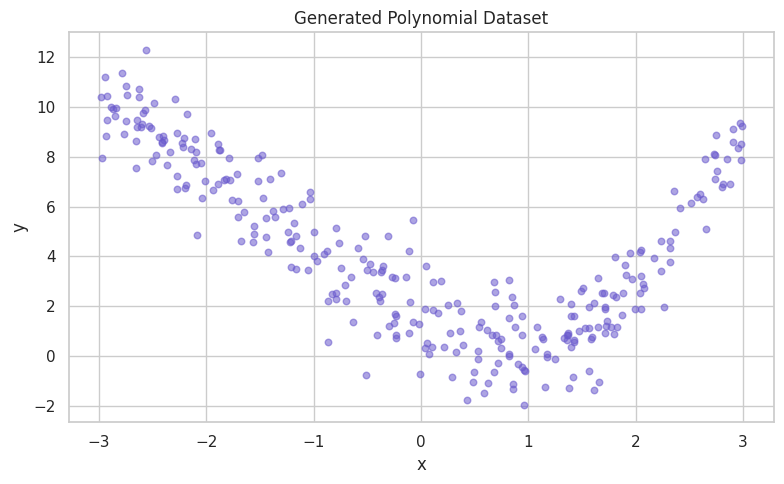

Polynomial data prepared.
Design matrix shape: (300, 4)


In [8]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [9]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Method,Final MSE,Epochs to Converge,Training Time (s)
0,Batch GD,1.504410,208,0.148765
1,SGD,1.338743,12,0.770546
2,Mini-Batch GD,1.337146,89,0.399306


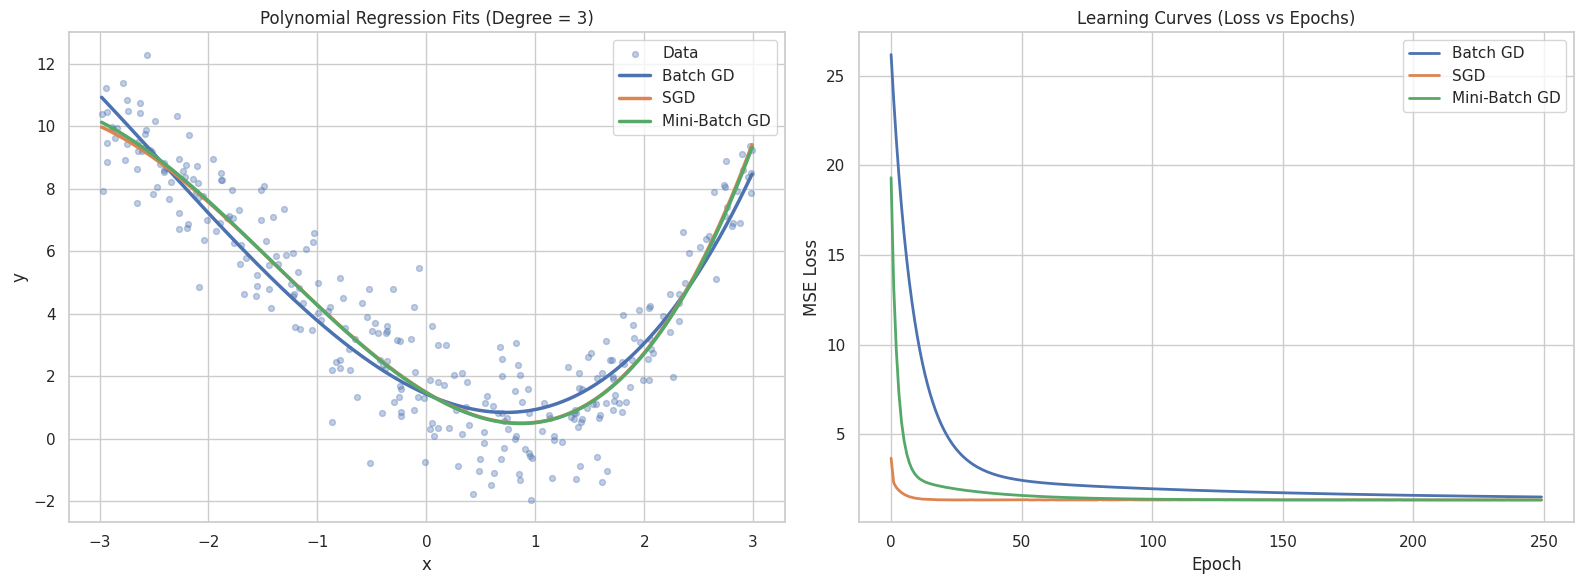

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.337146,89,0.399306
1,SGD,1.338743,12,0.770546
0,Batch GD,1.504410,208,0.148765


In [10]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

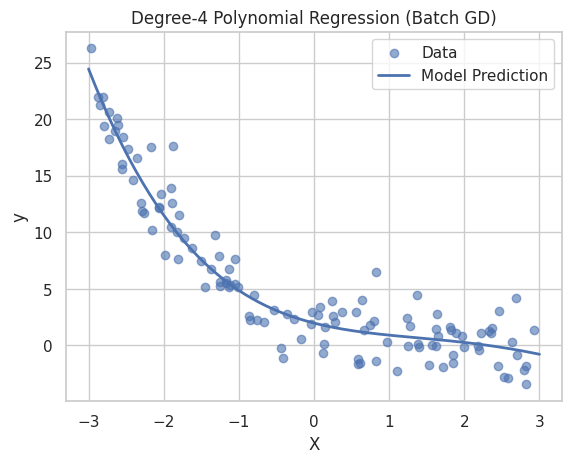

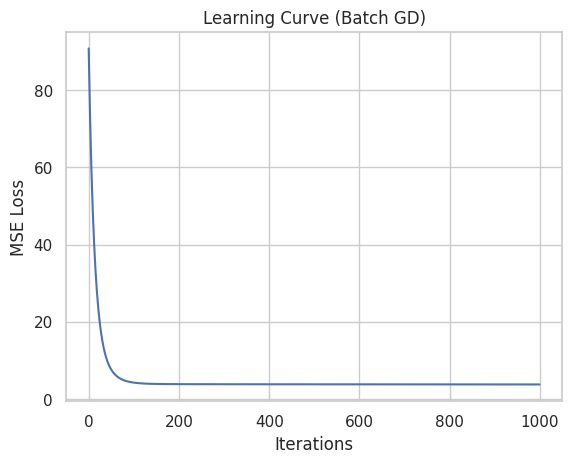

In [11]:
# ================================
# Task 1: Batch Gradient Descent for Degree-4 Polynomial
# ================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)

# -------------------------------
# 1. Generate Synthetic Dataset
# -------------------------------
m = 120
X = np.random.uniform(-3, 3, (m, 1))

# True function (different from tutorial)
y = (
    2
    - 1.5 * X
    + 0.7 * X**2
    - 0.3 * X**3
    + 0.05 * X**4
    + np.random.randn(m, 1) * 2
)

# -------------------------------
# 2. Polynomial Features (Degree 4)
# -------------------------------
poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X)

# -------------------------------
# 3. Feature Scaling
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Add bias term manually
X_b = np.c_[np.ones((m, 1)), X_scaled]

# -------------------------------
# 4. Batch Gradient Descent
# -------------------------------
def batch_gradient_descent(X, y, lr=0.01, n_iters=1000):
    m = len(y)
    theta = np.random.randn(X.shape[1], 1)
    loss_history = []

    for i in range(n_iters):
        gradients = (2/m) * X.T.dot(X.dot(theta) - y)
        theta = theta - lr * gradients

        loss = (1/m) * np.sum((X.dot(theta) - y) ** 2)
        loss_history.append(loss)

    return theta, loss_history

theta, loss_history = batch_gradient_descent(X_b, y)

# -------------------------------
# 5. Predictions for Plot
# -------------------------------
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_scaled = scaler.transform(X_new_poly)
X_new_b = np.c_[np.ones((200, 1)), X_new_scaled]

y_pred = X_new_b.dot(theta)

# -------------------------------
# 6. Plot Fitted Curve
# -------------------------------
plt.figure()
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X_new, y_pred, linewidth=2, label="Model Prediction")
plt.title("Degree-4 Polynomial Regression (Batch GD)")
plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# -------------------------------
# 7. Plot Learning Curve
# -------------------------------
plt.figure()
plt.plot(loss_history)
plt.title("Learning Curve (Batch GD)")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.show()

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

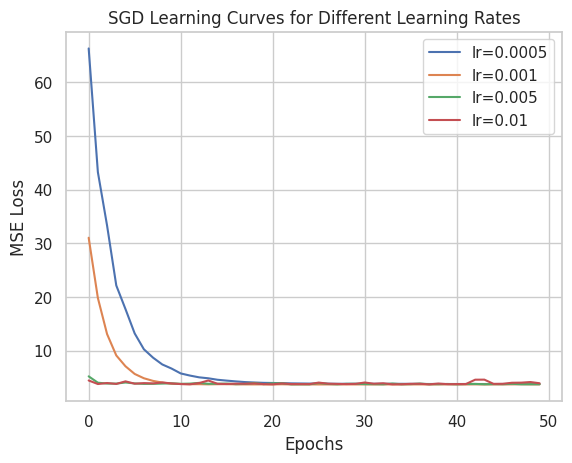

In [12]:
# ================================
# Task 2: Stochastic Gradient Descent + Learning Rate Tuning
# ================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)

# -------------------------------
# 1. Reuse Polynomial Dataset
# -------------------------------
m = 120
X = np.random.uniform(-3, 3, (m, 1))

y = (
    2
    - 1.5 * X
    + 0.7 * X**2
    - 0.3 * X**3
    + 0.05 * X**4
    + np.random.randn(m, 1) * 2
)

# Polynomial features
poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Add bias
X_b = np.c_[np.ones((m, 1)), X_scaled]

# -------------------------------
# 2. SGD Implementation
# -------------------------------
def stochastic_gradient_descent(X, y, lr=0.01, epochs=50):
    m = len(y)
    theta = np.random.randn(X.shape[1], 1)
    loss_history = []

    for epoch in range(epochs):
        for i in range(m):
            idx = np.random.randint(m)
            xi = X[idx:idx+1]
            yi = y[idx:idx+1]

            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - lr * gradients

        # Compute full loss after each epoch
        loss = (1/m) * np.sum((X.dot(theta) - y) ** 2)
        loss_history.append(loss)

    return theta, loss_history

# -------------------------------
# 3. Train with Different Learning Rates
# -------------------------------
learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}

for lr in learning_rates:
    _, history = stochastic_gradient_descent(X_b, y, lr=lr)
    sgd_histories[lr] = history

# -------------------------------
# 4. Plot Learning Curves
# -------------------------------
plt.figure()

for lr, history in sgd_histories.items():
    plt.plot(history, label=f"lr={lr}")

plt.title("SGD Learning Curves for Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

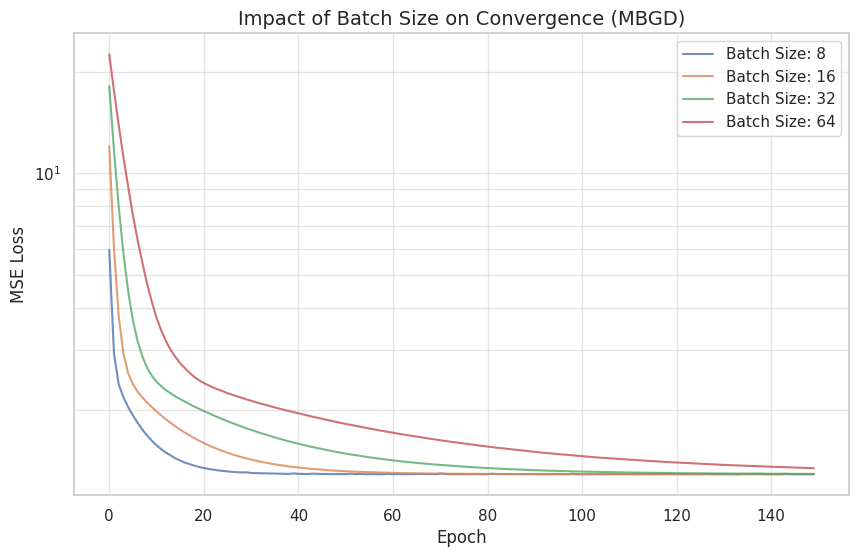

,Batch Size,Final MSE,Training Time (s)
0,8,1.292076,0.261779
1,16,1.291752,0.177298
2,32,1.294482,0.132154
3,64,1.345725,0.117759


In [13]:
# -----------------------------
# Task 3: Mini-Batch Size Study
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Setup consistent polynomial dataset (Degree 3 as used in tutorial)
# Re-using the logic from the tutorial to ensure a challenging non-linear fit
m_t3 = 400
x_t3 = np.random.uniform(-3, 3, size=(m_t3, 1))
y_t3 = 1.5 - 2.0 * x_t3 + 0.9 * (x_t3 ** 2) + 0.2 * (x_t3 ** 3) + np.random.randn(m_t3, 1) * 1.2

# Preprocessing: Polynomial features and scaling
poly_t3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_t3 = poly_t3.fit_transform(x_t3)
scaler_t3 = StandardScaler()
X_scaled_t3 = scaler_t3.fit_transform(X_poly_t3)
X_t3 = np.c_[np.ones((X_scaled_t3.shape[0], 1)), X_scaled_t3]

# 2. Study different batch sizes
batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

for bs in batch_sizes:
    # We keep lr=0.02 and epochs=150 constant to isolate the effect of batch size
    model = GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=150, batch_size=bs)
    model.fit(X_t3, y_t3)

    # Store history for plotting
    mbgd_histories[bs] = model.loss_history

    # Calculate metrics
    y_pred = model.predict(X_t3)
    mbgd_metrics.append({
        "Batch Size": bs,
        "Final MSE": mean_squared_error(y_t3, y_pred),
        "Training Time (s)": model.training_time
    })

# 3. Visualization
plt.figure(figsize=(10, 6))
for bs in batch_sizes:
    plt.plot(mbgd_histories[bs], label=f"Batch Size: {bs}", alpha=0.8)

plt.title("Impact of Batch Size on Convergence (MBGD)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log') # Log scale helps visualize convergence stability
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

# 4. Display Metric Table
summary_df = pd.DataFrame(mbgd_metrics)
display(summary_df)

## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.281157,40,0.139262
1,SGD,1.288255,8,0.775501
0,Batch GD,1.337649,149,0.100924


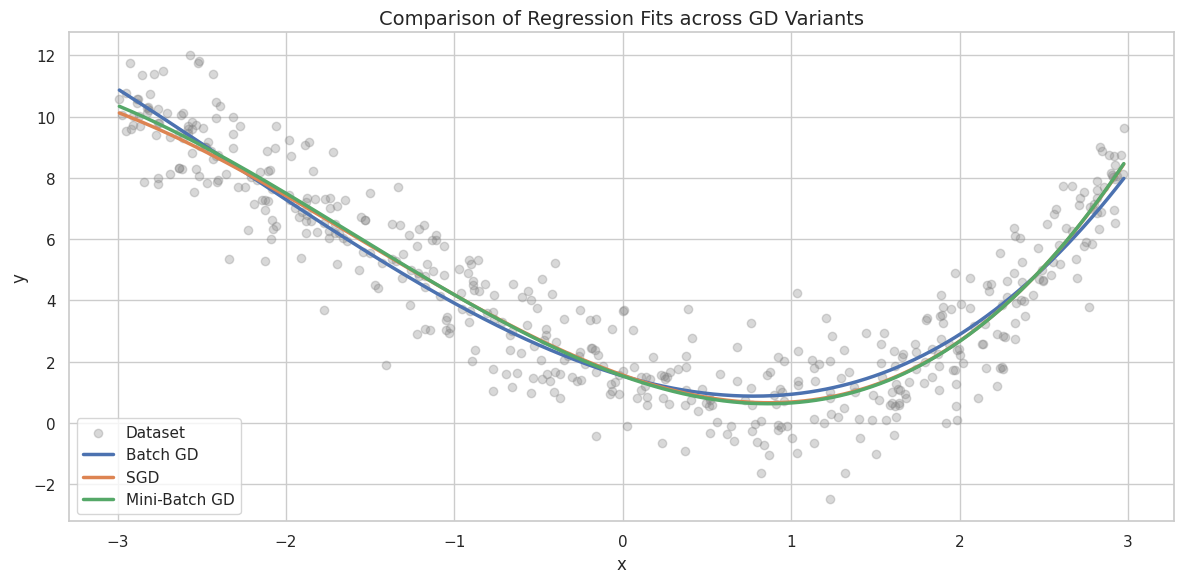

In [14]:
# -----------------------------
# Task 4: Comparative Analysis
# -----------------------------

# 1. Generate one shared dataset for all models
m_t4 = 500
x_t4 = np.random.uniform(-3, 3, size=(m_t4, 1))
y_t4 = 1.5 - 2.0 * x_t4 + 0.9 * (x_t4 ** 2) + 0.2 * (x_t4 ** 3) + np.random.randn(m_t4, 1) * 1.1

# Preprocessing (Degree 3)
poly_t4 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_t4 = poly_t4.fit_transform(x_t4)
scaler_t4 = StandardScaler()
X_scaled_t4 = scaler_t4.fit_transform(X_poly_t4)
X_t4 = np.c_[np.ones((X_scaled_t4.shape[0], 1)), X_scaled_t4]

# 2. Define models with tuned hyperparameters based on previous tasks
task4_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.1, epochs=200),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=200),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=200, batch_size=32)
}

task4_rows = []

# 3. Train and collect metrics
for name, model in task4_models.items():
    model.fit(X_t4, y_t4)
    y_pred = model.predict(X_t4)

    # Calculate Convergence (Epoch where loss is within 5% of final loss)
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    task4_rows.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_t4, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

# 4. Summary Table
summary_df = pd.DataFrame(task4_rows)
display(summary_df.sort_values("Final MSE"))

# 5. Visualization: Fitted Curves
x_line = np.linspace(x_t4.min(), x_t4.max(), 500).reshape(-1, 1)
X_line_scaled = scaler_t4.transform(poly_t4.transform(x_line))
X_line_design = np.c_[np.ones((X_line_scaled.shape[0], 1)), X_line_scaled]

plt.figure(figsize=(12, 6))
plt.scatter(x_t4, y_t4, alpha=0.3, color="gray", label="Dataset")

for name, model in task4_models.items():
    y_line_pred = model.predict(X_line_design)
    plt.plot(x_line, y_line_pred, label=name, linewidth=2.5)

plt.title("Comparison of Regression Fits across GD Variants", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**
The bias-variance tradeoff represents the struggle to find a model complexity that generalizes well to new data.

Degree too low (High Bias/Underfitting): The model is too simple to capture the underlying pattern of the data, such as trying to fit a straight line to a curved dataset. This results in high error on both training and test sets.

Degree too high (High Variance/Overfitting): The model becomes overly complex and begins to "memorize" the random noise and outliers in the training data rather than the actual trend. While training error will be very low, the model will fail significantly on new, unseen data.

### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**

Stochastic Gradient Descent (SGD) has higher variance because it calculates the gradient and updates parameters using only one training example at a time.

Why SGD is Noisy: Because individual data points can be outliers or contain noise, the direction of an update based on a single point might be very different from the true gradient of the entire dataset, leading to a "zigzag" or noisy path toward the minimum.

Batch GD Stability: Batch GD uses the average of all examples, providing a stable, accurate gradient that points directly toward the minimum.

Mini-Batch GD Balance: Mini-Batch GD balances this by using a small subset (batch) of data. This reduces the variance of the updates compared to SGD (making it smoother) while remaining more computationally efficient than Batch GD.

### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**

Feature scaling is critical for Gradient Descent because it ensures that all polynomial terms contribute proportionately to the weight updates.The Problem with Polynomial Terms: In polynomial regression, features are raised to powers (e.g., $x^2, x^3, x^4$). If $x$ ranges from 1 to 10, then $x^4$ ranges from 1 to 10,000.Elongated Cost Contours: Without scaling, the cost function $J(\theta)$ becomes highly "stretched" or elongated like a deep, narrow canyon.Consequences: * Slow Convergence: The gradient descent may oscillate back and forth across the narrow valley, requiring a very small learning rate and many more iterations to reach the minimum.Numerical Instability: The model may fail to converge entirely or suffer from "exploding gradients" as the weights for higher-degree terms grow uncontrollably.

# 6) Conclusion

In this lab, you:
- Implemented **Batch GD**, **SGD**, and **Mini-Batch GD** from scratch using NumPy.
- Compared optimization behavior through loss curves and empirical metrics.
- Applied gradient descent methods to **polynomial regression** with feature engineering.
- Explored practical tuning effects of learning rate and batch size.

Key takeaway: there is no single universally best optimizer setup. Effective training depends on balancing learning rate, batch size, feature scaling, and computational constraints.